# HMM-SVR-L Regime-Aware Volatility Forecasting

## Overview

This notebook implements the two-step Hidden Markov Model plus linear Support Vector Regression (HMM-SVR-L) workflow used to forecast one-day-ahead Bitcoin realized variance. It uses the HMM output in `df_hmm.csv`, especially the forward-looking high-volatility regime probability `hmm_prob_high_t1`, as an input feature for a rolling SVR volatility forecaster.

The purpose of the notebook is to test whether regime information improves volatility forecasting compared with regime-unaware baselines. The object being forecast is next-day log realized variance, which is later exponentiated back to the realized variance scale for evaluation and export.

The notebook is structured as follows:

1. Load libraries, set the random seed, and import the HMM-enhanced modelling dataset.
2. Define the SVR feature set, including market, blockchain, macro, lagged realized variance, and HMM regime-probability variables.
3. Define evaluation utilities and the rolling one-step-ahead SVR forecasting function.
4. Split the data into training, validation, evaluation, and test windows.
5. Tune SVR hyperparameters on the evaluation window, refit using the selected parameters, and evaluate validation/test performance.
6. Export forecast results and summary metrics, then plot actual versus predicted realized variance and forecast errors.


In [2]:
import pandas as pd
import numpy as np
import random
from itertools import product

from sklearn.svm import LinearSVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

In [5]:

# Load HMM dataset (contains hmm_prob_high_t1)
df = pd.read_csv("df_hmm.csv", parse_dates=["date"])
df = df.sort_values("date").reset_index(drop=True)

df = df.dropna(subset=[
    "hmm_regime",
    "hmm_prob_high_t1",
    "rvar_1",
    "rvar_2",
    "rvar_3",
    "rvar_30",
    "log_realized_variance"
]).reset_index(drop=True)

print("Rows:", len(df))
print("Date range:", df["date"].min(), "->", df["date"].max())
df.head()

Rows: 3153
Date range: 2017-06-14 00:00:00 -> 2026-01-30 00:00:00


,date,log_return,realized_variance,realized_volatility,gtrend_pct_change,blockchain_diff_log_n_transactions,blockchain_diff_log_transaction_fee_usd,blockchain_diff_log_n_unique_addresses,blockchain_diff_log_transaction_volume_usd,log_volume,...,rvar_3,rvar_7,rvar_30,hmm_regime,hmm_prob_high,hmm_prob_high_t1,hmm_regime_lag1,hmm_prob_high_lag1,hmm_prob_high_lag2,hmm_prob_high_roll5
0,2017-06-14,-0.107783,0.005921,0.076946,-0.083333,-0.014263,-0.062838,-0.077079,-0.019709,10.249137,...,-7.076272,-6.221144,-6.101790,1.0,1.000000,0.039629,NaN,NaN,NaN,NaN
1,2017-06-15,-0.009182,0.025532,0.159788,0.298701,0.018930,-0.177964,0.013878,-0.155374,10.646045,...,-4.522040,-5.782948,-5.981209,1.0,0.999999,0.040121,1.0,1.000000,NaN,NaN
2,2017-06-16,0.028813,0.004461,0.066787,-0.230000,-0.082465,-0.112954,-0.067719,-0.135638,9.993920,...,-6.618726,-5.505681,-5.934919,1.0,1.000000,0.039955,1.0,0.999999,1.000000,NaN
3,2017-06-17,0.060428,0.001743,0.041744,-0.129870,-0.132012,-0.121297,-0.116133,-0.149550,9.775786,...,-5.129306,-5.539863,-5.894006,1.0,1.000000,0.039543,1.0,1.000000,0.999999,NaN
4,2017-06-18,-0.046488,0.003086,0.055553,-0.074627,-0.122126,-0.127078,-0.097003,0.003247,9.534784,...,-3.667819,-5.354801,-5.851067,1.0,1.000000,0.039189,1.0,1.000000,1.000000,NaN


In [11]:
# Same stage-2 SVR features as lstm_regime6
#svr_features = ["rv_lag1", "rv_lag2", "rv_lag3", "rv_rolling_mean_30"]

svr_features = [
    "log_return",
    "gtrend_pct_change",
    "blockchain_diff_log_n_transactions",
    "blockchain_diff_log_transaction_fee_usd",
    "blockchain_diff_log_n_unique_addresses",
    "blockchain_diff_log_transaction_volume_usd",
    "log_volume",
    "gold_close_ret",
    "silver_close_ret",
    "brent_close_ret",
    "dji_close_ret",
    "spx_close_ret",
    "rut_close_ret",
    "nasdaq_close_ret",
    "usdcny_close_ret",
    "usdeur_close_ret",
    "gold_volume_chg",
    "silver_volume_chg",
    "brent_volume_chg",
    "dji_volume_chg",
    "spx_volume_chg",
    "rut_volume_chg",
    "nasdaq_volume_chg",
    "vix_close_chg",
    "hash-rate_chg",
    "difficulty_chg",
    "median-confirmation-time_chg",
    "blockchain_log_mempool_count_chg",
    "rvar_30",
    "rvar_1",
    "rvar_2",
    "rvar_3",
    "hmm_prob_high_t1"
]


In [12]:
def rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    if mask.sum() == 0:
        return np.nan
    return np.sqrt(np.mean((y_true[mask] - y_pred[mask]) ** 2))


def qlike(test_actuals, test_preds): 
    test_actuals = np.asarray(test_actuals, dtype=float)
    test_preds = np.asarray(test_preds, dtype=float)

    test_qlike = np.mean(test_actuals / (test_preds + 1e-10) - np.log(test_actuals / (test_preds + 1e-10)) - 1)

    return test_qlike 


In [13]:
def one_step_svr_forecast(fitted_svr, x_next):
    if fitted_svr is None:
        return np.nan
    try:
        return float(fitted_svr.predict(x_next)[0])
    except Exception:
        return np.nan


def fit_svr_safe(X_train, y_train, C=1.0, epsilon=1e-4, min_obs=200):
    if len(X_train) < min_obs:
        return None
    try:
        model = LinearSVR(C=C, epsilon=epsilon, dual=True,
                          max_iter=20000, random_state=SEED)
        model.fit(X_train, y_train)
        return model
    except Exception as e:
        print("LinearSVR fit failed:", e)
        return None


def rolling_hmm_svr_linear_eval(
    df_full,
    start_idx,
    end_idx,
    x_feature_cols,
    realized_var_col="log_realized_variance",
    hmm_prob_t1_col="hmm_prob_high_t1",
    date_col="date",
    rolling_window=365,
    C=1.0,
    epsilon=1e-4,
    min_obs=200,
):
    """
    Rolling one-step-ahead SVR-L forecast.
    - Trains on log_realized_variance (log scale)
    - hmm_prob_high_t1 is forward-looking — no look-ahead bias
    - Predictions exponentiated back to variance scale for evaluation
    """
    results = []
    df = df_full.copy()

    # Next-day log variance target
    df["rv_lead1"] = df[realized_var_col].shift(-1)

    for t in range(start_idx - 1, end_idx - 1):
        if t < 0 or (t + 1) >= len(df):
            continue

        current_row = df.iloc[t]
        next_row    = df.iloc[t + 1]

        current_date = current_row[date_col]
        next_date    = next_row[date_col]

        # Rolling training window ending at t-1
        window_df = df.iloc[max(0, t - rolling_window + 1): t].copy()
        train_df  = window_df[x_feature_cols + ["rv_lead1"]].dropna()

        if len(train_df) < min_obs:
            results.append({
                "date":                next_date,
                "forecast_origin_date": current_date,
                "actual_log_var":      next_row[realized_var_col],
                "log_var_svr":         np.nan,
            })
            continue

        X_train = train_df[x_feature_cols].values
        y_train = train_df["rv_lead1"].values

        # Standardise
        scaler         = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)

        fitted_svr = fit_svr_safe(X_train_scaled, y_train, C=C,
                                   epsilon=epsilon, min_obs=min_obs)

        # Forecast using features at t (hmm_prob_high_t1 already for t+1)
        x_next_raw    = current_row[x_feature_cols].values.reshape(1, -1)
        x_next_scaled = scaler.transform(x_next_raw)

        log_var_forecast = one_step_svr_forecast(fitted_svr, x_next_scaled)

        results.append({
            "date":                next_date,
            "forecast_origin_date": current_date,
            "actual_log_var":      next_row[realized_var_col],
            "log_var_svr":         log_var_forecast,
        })

    results_df = pd.DataFrame(results)
    results_df["actual_log_var"] = pd.to_numeric(results_df["actual_log_var"],
                                                   errors="coerce")
    results_df["log_var_svr"]    = pd.to_numeric(results_df["log_var_svr"],
                                                   errors="coerce")
    return results_df

In [14]:
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

test_end_date = pd.Timestamp("2026-01-31")
test_len      = 469

end_matches = df.index[df["date"] == test_end_date]
if len(end_matches) == 0:
    raise ValueError(f"test_end_date {test_end_date.date()} not found in df['date']")

test_end_idx   = int(end_matches[0]) + 1
test_start_idx = test_end_idx - test_len
if test_start_idx < 0:
    raise ValueError("Not enough rows before test_end_date for 469 test samples.")

train_eval_end_idx = test_start_idx
train_size = int(train_eval_end_idx * (12.0 / 17.0))
train_size = max(1, min(train_size, train_eval_end_idx - 1))
eval_size  = train_eval_end_idx - train_size

train_start_idx = 0
train_end_idx   = train_size
eval_start_idx  = train_end_idx
eval_end_idx    = train_eval_end_idx

evalA_size      = max(1, eval_size // 2)
evalA_start_idx = eval_start_idx
evalA_end_idx   = evalA_start_idx + evalA_size
evalB_start_idx = evalA_end_idx
evalB_end_idx   = eval_end_idx

print("Train:", train_start_idx, "->", train_end_idx)
print("EvalA:", evalA_start_idx, "->", evalA_end_idx)
print("EvalB:", evalB_start_idx, "->", evalB_end_idx)
print("Test: ", test_start_idx,  "->", test_end_idx)
print("Test date range:", df.loc[test_start_idx, "date"].date(),
      "->", df.loc[test_end_idx - 1, "date"].date())

Train: 0 -> 1894
EvalA: 1894 -> 2289
EvalB: 2289 -> 2684
Test:  2684 -> 3153
Test date range: 2024-10-19 -> 2026-01-30


In [15]:
svr_grid = {
    "C":       [0.1, 1.0, 10.0],
    "epsilon": [1e-4, 1e-3, 1e-2],
}
svr_param_grid = [{"C": C, "epsilon": e}
                  for C, e in product(svr_grid["C"], svr_grid["epsilon"])]

stage2_window = 365
min_obs       = 200

svr_results = []
for i, params in enumerate(svr_param_grid, 1):
    print(f"[{i}/{len(svr_param_grid)}] Testing SVR: {params}")

    evalB_svr = rolling_hmm_svr_linear_eval(
        df_full=df,
        start_idx=evalB_start_idx,
        end_idx=evalB_end_idx,
        x_feature_cols=svr_features,
        rolling_window=stage2_window,
        C=float(params["C"]),
        epsilon=float(params["epsilon"]),
        min_obs=min_obs,
    )

    evalB_rmse  = rmse(evalB_svr["actual_log_var"], evalB_svr["log_var_svr"])
    evalB_qlike = qlike(
        np.exp(evalB_svr["actual_log_var"]),
        np.exp(evalB_svr["log_var_svr"])
    )

    svr_results.append({
        "C":                 params["C"],
        "epsilon":           params["epsilon"],
        "evalB_rmse":        evalB_rmse,
        "evalB_qlike":       evalB_qlike,
        "n_evalB_forecasts": int(evalB_svr["log_var_svr"].notna().sum()),
    })

svr_results_df = pd.DataFrame(svr_results).sort_values("evalB_qlike")
print(svr_results_df)

[1/9] Testing SVR: {'C': 0.1, 'epsilon': 0.0001}
[2/9] Testing SVR: {'C': 0.1, 'epsilon': 0.001}
[3/9] Testing SVR: {'C': 0.1, 'epsilon': 0.01}
[4/9] Testing SVR: {'C': 1.0, 'epsilon': 0.0001}
[5/9] Testing SVR: {'C': 1.0, 'epsilon': 0.001}
[6/9] Testing SVR: {'C': 1.0, 'epsilon': 0.01}
[7/9] Testing SVR: {'C': 10.0, 'epsilon': 0.0001}


/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the n

[8/9] Testing SVR: {'C': 10.0, 'epsilon': 0.001}


/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the n

[9/9] Testing SVR: {'C': 10.0, 'epsilon': 0.01}


/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the n

      C  epsilon  evalB_rmse  evalB_qlike  n_evalB_forecasts
2   0.1   0.0100    1.013883     0.472817                395
1   0.1   0.0010    1.014753     0.474704                395
0   0.1   0.0001    1.014786     0.474811                395
3   1.0   0.0001    1.019130     0.606103                395
5   1.0   0.0100    1.018601     0.607325                395
4   1.0   0.0010    1.019650     0.608355                395
8  10.0   0.0100    1.024641     0.629453                395
7  10.0   0.0010    1.027272     0.631610                395
6  10.0   0.0001    1.027743     0.631845                395


In [16]:
best_svr_params = svr_results_df.iloc[0].to_dict()
print("Best SVR params:", best_svr_params)

Best SVR params: {'C': 0.1, 'epsilon': 0.01, 'evalB_rmse': 1.0138826239385348, 'evalB_qlike': 0.4728173891956514, 'n_evalB_forecasts': 395.0}


In [17]:
val_svr = rolling_hmm_svr_linear_eval(
    df_full=df,
    start_idx=eval_start_idx,
    end_idx=eval_end_idx,
    x_feature_cols=svr_features,
    rolling_window=stage2_window,
    C=float(best_svr_params["C"]),
    epsilon=float(best_svr_params["epsilon"]),
    min_obs=min_obs,
)

if len(val_svr) == 0:
    raise ValueError("No forecasts produced on validation set.")

# Metrics on log scale
val_rmse_log = rmse(val_svr["actual_log_var"], val_svr["log_var_svr"])

# Exponentiate back to variance scale for interpretable metrics
val_rmse_var = rmse(
    np.exp(val_svr["actual_log_var"]),
    np.exp(val_svr["log_var_svr"])
)
val_mae_var  = mean_absolute_error(
    np.exp(val_svr["actual_log_var"]),
    np.exp(val_svr["log_var_svr"])
)
val_qlike    = qlike(
    np.exp(val_svr["actual_log_var"]),
    np.exp(val_svr["log_var_svr"])
)

print("Validation RMSE (log-var):", val_rmse_log)
print("Validation RMSE (var):    ", val_rmse_var)
print("Validation MAE  (var):    ", val_mae_var)
print("Validation QLIKE:         ", val_qlike)
print("N forecasts:              ", int(val_svr["log_var_svr"].notna().sum()))

Validation RMSE (log-var): 1.1120124888297143
Validation RMSE (var):     0.0009169636481039437
Validation MAE  (var):     0.00047671379940172404
Validation QLIKE:          0.6021735142758572
N forecasts:               790


In [18]:
test_svr = rolling_hmm_svr_linear_eval(
    df_full=df,
    start_idx=test_start_idx,
    end_idx=test_end_idx,
    x_feature_cols=svr_features,
    rolling_window=stage2_window,
    C=float(best_svr_params["C"]),
    epsilon=float(best_svr_params["epsilon"]),
    min_obs=min_obs,
)

if len(test_svr) == 0:
    raise ValueError("No forecasts produced on test set.")

# Metrics on log scale
test_rmse_log = rmse(test_svr["actual_log_var"], test_svr["log_var_svr"])

# Exponentiate back to variance scale
test_rmse_var = rmse(
    np.exp(test_svr["actual_log_var"]),
    np.exp(test_svr["log_var_svr"])
)
test_mae_var  = mean_absolute_error(
    np.exp(test_svr["actual_log_var"]),
    np.exp(test_svr["log_var_svr"])
)
test_qlike    = qlike(
    np.exp(test_svr["actual_log_var"]),
    np.exp(test_svr["log_var_svr"])
)

print("Test RMSE (log-var):", test_rmse_log)
print("Test RMSE (var):    ", test_rmse_var)
print("Test MAE  (var):    ", test_mae_var)
print("Test QLIKE:         ", test_qlike)
print("N forecasts:        ", int(test_svr["log_var_svr"].notna().sum()))

Test RMSE (log-var): 1.0584928425160784
Test RMSE (var):     0.0006455496913434245
Test MAE  (var):     0.0003867578538640202
Test QLIKE:          0.4466729323526748
N forecasts:         469


In [19]:

summary = pd.DataFrame({
    "metric": ["test_rmse_log", "test_rmse_var", "test_mae_var", "test_qlike", "n_test_forecasts"],
    "value": [
        test_rmse_log,
        test_rmse_var,
        test_mae_var,
        test_qlike,
        int(test_svr["log_var_svr"].notna().sum()),
    ],
})
summary


,metric,value
0,test_rmse_log,1.058493
1,test_rmse_var,0.000646
2,test_mae_var,0.000387
3,test_qlike,0.446673
4,n_test_forecasts,469.000000


In [20]:
summary = pd.DataFrame({
    "metric": ["test_rmse_log", "test_rmse_var", "test_mae_var",
                "test_qlike",   "n_test_forecasts"],
    "value":  [test_rmse_log,   test_rmse_var,   test_mae_var,
                test_qlike,     int(test_svr["log_var_svr"].notna().sum())],
})
print(summary)

             metric       value
0     test_rmse_log    1.058493
1     test_rmse_var    0.000646
2      test_mae_var    0.000387
3        test_qlike    0.446673
4  n_test_forecasts  469.000000


In [21]:
import os
os.makedirs("results", exist_ok=True)

test_export = test_svr.copy()

# Exponentiate back to variance scale for export
test_export["actual_var"]   = np.exp(test_export["actual_log_var"])
test_export["forecast_var"] = np.exp(test_export["log_var_svr"])
test_export["error_var"]    = test_export["actual_var"] - test_export["forecast_var"]

test_export.to_csv("results/hmm_svrl_revised_test_results.csv", index=False)
summary.to_csv("results/hmm_svrl_revised_summary.csv", index=False)

## Summary and Plots


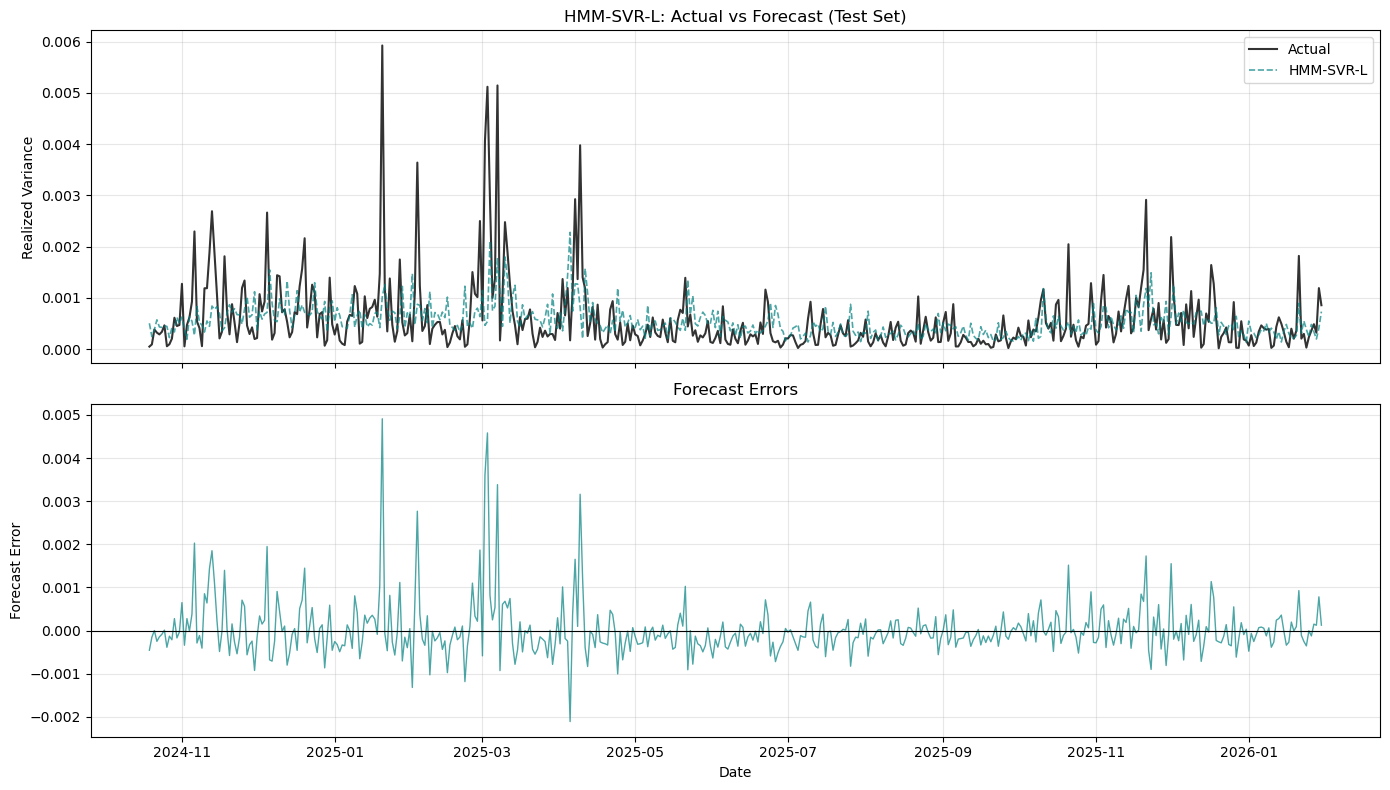

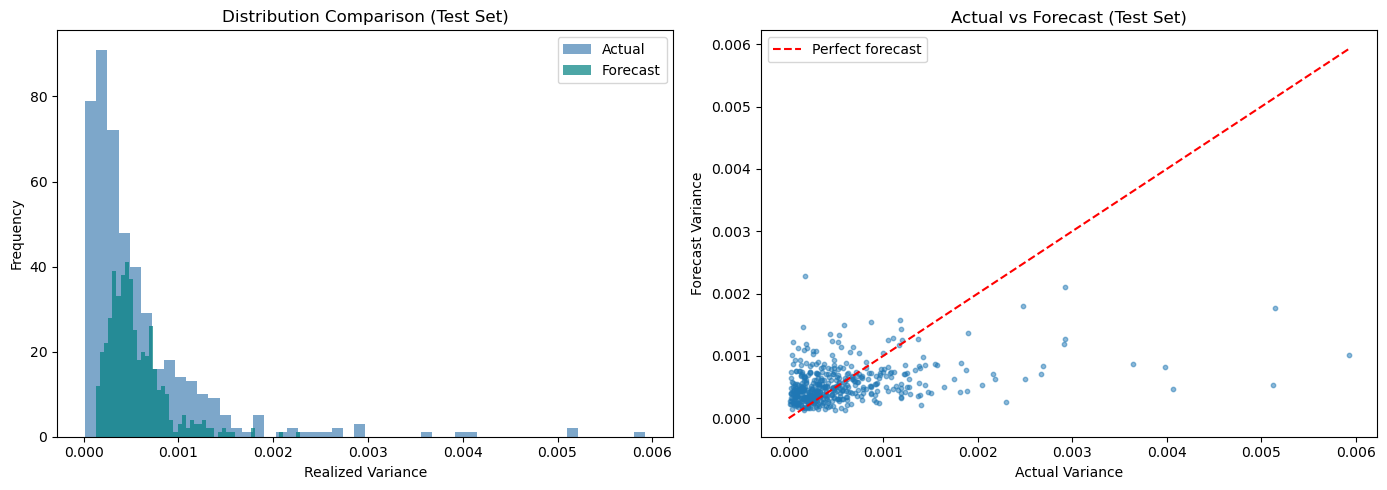


Forecast Statistics (Test Set):
  Mean forecast: 0.000545
  Mean actual:   0.000569
  Forecast std:  0.000300
  Actual std:    0.000689
  Forecasts > Actuals: 61.2%


In [22]:
import matplotlib.pyplot as plt

test_export["date"] = pd.to_datetime(test_export["date"])
test_export = test_export.sort_values("date").reset_index(drop=True)

plot_dates     = test_export["date"].to_numpy()
plot_actuals   = test_export["actual_var"].to_numpy()    # variance scale
plot_forecasts = test_export["forecast_var"].to_numpy()  # variance scale
plot_errors    = test_export["error_var"].to_numpy()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(plot_dates, plot_actuals,   label="Actual",    color="black", linewidth=1.5, alpha=0.8)
axes[0].plot(plot_dates, plot_forecasts, label="HMM-SVR-L", color="teal",  linewidth=1.2, alpha=0.7, linestyle="--")
axes[0].set_ylabel("Realized Variance")
axes[0].set_title("HMM-SVR-L: Actual vs Forecast (Test Set)")
axes[0].legend(loc="upper right")
axes[0].grid(True, alpha=0.3)

axes[1].plot(plot_dates, plot_errors, color="teal", linewidth=1, alpha=0.7)
axes[1].axhline(y=0, color="black", linestyle="-", linewidth=0.8)
axes[1].set_ylabel("Forecast Error")
axes[1].set_xlabel("Date")
axes[1].set_title("Forecast Errors")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Distribution & scatter
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(plot_actuals,   bins=50, alpha=0.7, label="Actual",   color="steelblue")
axes[0].hist(plot_forecasts, bins=50, alpha=0.7, label="Forecast", color="teal")
axes[0].set_xlabel("Realized Variance")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Distribution Comparison (Test Set)")
axes[0].legend()

max_val = max(plot_actuals.max(), plot_forecasts.max())
axes[1].scatter(plot_actuals, plot_forecasts, alpha=0.5, s=10)
axes[1].plot([0, max_val], [0, max_val], "r--", label="Perfect forecast")
axes[1].set_xlabel("Actual Variance")
axes[1].set_ylabel("Forecast Variance")
axes[1].set_title("Actual vs Forecast (Test Set)")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nForecast Statistics (Test Set):")
print(f"  Mean forecast: {plot_forecasts.mean():.6f}")
print(f"  Mean actual:   {plot_actuals.mean():.6f}")
print(f"  Forecast std:  {plot_forecasts.std():.6f}")
print(f"  Actual std:    {plot_actuals.std():.6f}")
print(f"  Forecasts > Actuals: {(plot_forecasts > plot_actuals).mean()*100:.1f}%")